# 3I - Interpretacao integrada da Fase 3 (Pacifico; NOAA/ONI local)

**Pergunta especifica.** Depois de 3A-3H/3K, qual conjunto de variaveis explica o aquecimento maximo do El Nino com antecedencia, quais evidencias entram no parecer e qual e a leitura cautelosa para 2025/26?

**Justificativa.** A Fase 3 precisa separar diagnostico fisico, triagem preditiva e previsao operacional. O hindcast leave-one-event-out (LOO) e uma metodologia conhecida para amostras pequenas, mas quando o proprio LOO escolhe o melhor modelo/horizonte ele fica otimista. Por isso esta versao usa **nested LOO**: o loop interno seleciona o candidato dentro do treino; o loop externo avalia o evento deixado fora.

**Objetivo.** Integrar ranking fisico, classes NOAA/ONI locais, estado 2025/26 e um protocolo preditivo defensavel para estimar amplitude do pico condicionada ao estado recente.

**Metodologia.** (1) Consolidar resultados 3A-3H/3K; (2) medir skill por variavel com LOO simples apenas como triagem; (3) avaliar selecao de modelo por nested LOO contra climatologia LOO; (4) gerar uma projecao condicional, ainda nao operacional, usando a regra de selecao ja avaliada; (5) documentar referencias: recarga ENSO (Jin; Meinen & McPhaden), verificacao sazonal/hindcast (WMO/Barnston) e controle de vies de selecao (Ambroise & McLachlan; Cawley & Talbot).

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_conjunto_antecipacao_pico.csv`, `phase3I_classificacao_noaa_oni.csv`, `phase3I_medias_classes_noaa.csv`, `phase3I_estado_2026.csv`, `3I1_sintese_parecer.png`, `3I2_antecipacao_pico.png`, `phase3I_skill_por_variavel.csv`, `phase3I_modelos_candidatos.csv`, `phase3I_skill_horizontes.csv`, `phase3I_nested_loo_eventos.csv`, `phase3I_nested_loo_metricas.csv`, `phase3I_nested_loo_selecao.csv`, `phase3I_projecao_pico_2026.csv`, `3I3_previsao_condicional_nested.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u

d3 = pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3 = pd.read_csv(u.STATS/'phase3E_estabilidade.csv').set_index('variavel')
assert not any('atl' in v for v in d3.index), 'Atlantico ainda presente!'
print('Variaveis no parecer (todas Pacifico):', list(d3.index))
bloco = {
    'tilt_m':'recarga/subsuperficie', 'ssh_m':'recarga/subsuperficie', 'ohc_0_300':'recarga/subsuperficie',
    'ohc_0_700':'recarga/subsuperficie', 'd20_m':'recarga/subsuperficie', 'wwv':'recarga/subsuperficie',
    'tau_x_anom_nino34_pa':'vento/acoplamento',
}
rows = []
for v in d3.index:
    estavel = bool(e3.loc[v, 'estavel']) if v in e3.index else False
    lag = int(d3.loc[v, 'lag_semanas'])
    r = float(d3.loc[v, 'r'])
    if lag >= 12 and estavel:
        papel = 'precursor antecipado'
        uso = 'entra como candidato para previsao do pico'
    elif lag > 0:
        papel = 'precursor curto/medio prazo'
        uso = 'entra como apoio diagnostico'
    else:
        papel = 'estado simultaneo/acoplado'
        uso = 'entra como diagnostico de estado'
    if not estavel:
        uso = 'entra com ressalva (regime-dependente)'
    rows.append({'variavel':v, 'rotulo':u.var_label(v, short=True), 'bloco':bloco.get(v, '-'), 'lag_semanas':lag, 'r':round(r, 3), 'abs_r':round(abs(r), 3), 'estavel_3E':estavel, 'papel':papel, 'uso_parecer':uso})
conc = pd.DataFrame(rows).sort_values(['abs_r','lag_semanas'], ascending=[False, False])
u.save_table(conc, 'phase3I_conclusoes_decisao.csv', index=False)
antecip = conc.assign(horizonte=np.select([conc['lag_semanas']>=26, conc['lag_semanas']>=12, conc['lag_semanas']>0], ['longo (>=6 meses)','medio (3-6 meses)','curto (<3 meses)'], default='simultaneo'))
antecip['interpreta_para_2026'] = antecip.apply(lambda r: 'priorizar na futura projecao de pico' if (r['estavel_3E'] and r['lag_semanas']>=12) else ('usar como estado/acoplamento atual' if r['lag_semanas']<=6 else 'usar com cautela'), axis=1)
u.save_table(antecip, 'phase3I_conjunto_antecipacao_pico.csv', index=False)
print(antecip[['rotulo','bloco','lag_semanas','r','estavel_3E','horizonte','interpreta_para_2026']].to_string(index=False))

Variaveis no parecer (todas Pacifico): ['tilt_m', 'ssh_m', 'ohc_0_300', 'ohc_0_700', 'd20_m', 'wwv', 'tau_x_anom_nino34_pa']
[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv
[tabela] data\processed\parquet\statistics\phase3I_conjunto_antecipacao_pico.csv
     rotulo                 bloco  lag_semanas     r  estavel_3E         horizonte                 interpreta_para_2026
       Tilt recarga/subsuperficie            0 0.772        True        simultaneo   usar como estado/acoplamento atual
        SSH recarga/subsuperficie            6 0.755        True  curto (<3 meses)   usar como estado/acoplamento atual
   OHC0-300 recarga/subsuperficie            6 0.738        True  curto (<3 meses)   usar como estado/acoplamento atual
   OHC0-700 recarga/subsuperficie            6 0.701        True  curto (<3 meses)   usar como estado/acoplamento atual
        D20 recarga/subsuperficie           15 0.545        True medio (3-6 meses) priorizar na futura projecao de pico


In [2]:
ev_all = u.events_noaa()
counts = ev_all['classe_noaa'].value_counts().to_dict()
classes = u.elnino_mean_group_table()[['grupo','rotulo','definicao']].copy()
classes['n_eventos'] = classes['grupo'].map(lambda g: int(counts.get(g,0)))
classes['limiar_evento_oni_c'] = 0.5
classes['criterio_temporal'] = 'media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas'
classes['fonte_metodologica'] = 'NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL'
u.save_table(classes,'phase3I_classificacao_noaa_oni.csv',index=False)
print(classes.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_classificacao_noaa_oni.csv
      grupo                                     rotulo                                                           definicao  n_eventos  limiar_evento_oni_c                                           criterio_temporal                                              fonte_metodologica
      fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
   moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
      forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 

In [3]:
# medias executivas por classe NOAA/ONI local
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
base_media = taxas.copy()

def _stat(frame, col, func='mean', ndigits=3):
    s = frame[col].dropna()
    if s.empty:
        return np.nan
    val = getattr(s, func)()
    return round(float(val), ndigits)

def _media_row(grupo, frame):
    return {
        'grupo': grupo,
        'n_eventos': int(len(frame)),
        'oni_pico_medio_c': _stat(frame, 'oni_pico_c', 'mean', 3),
        'oni_pico_min_c': _stat(frame, 'oni_pico_c', 'min', 3),
        'oni_pico_max_c': _stat(frame, 'oni_pico_c', 'max', 3),
        'duracao_media_estacoes_oni': _stat(frame, 'duracao_estacoes_oni', 'mean', 2),
        'crescimento_medio_c_mes': _stat(frame, 'crescimento_c_por_mes', 'mean', 3),
        'decaimento_medio_c_mes': _stat(frame, 'decaimento_c_por_mes', 'mean', 3),
    }

group_frames = {g: base_media.query('classe == @g') for g in u.ELNINO_MEAN_GROUP_ORDER}
meta = u.elnino_mean_group_table()[['grupo', 'rotulo_curto', 'rotulo', 'definicao']]
media = meta.merge(pd.DataFrame([_media_row(g, group_frames[g]) for g in u.ELNINO_MEAN_GROUP_ORDER]), on='grupo', how='left')
u.save_table(media, 'phase3I_medias_classes_noaa.csv', index=False)
print(media.to_string(index=False))

[tabela] data\processed\parquet\statistics\phase3I_medias_classes_noaa.csv
      grupo rotulo_curto                                     rotulo                                                           definicao  n_eventos  oni_pico_medio_c  oni_pico_min_c  oni_pico_max_c  duracao_media_estacoes_oni  crescimento_medio_c_mes  decaimento_medio_c_mes
      fraco        Fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4             0.858           0.652           0.968                        6.00                    0.224                  -0.027
   moderado     Moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2             1.212           1.211           1.213                       12.00                    0.110                  -0.098
      forte        Forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 meses

In [4]:
daily = u.load_daily_nino34()
last = daily.index.max()
monthly = pd.read_csv(u.FEAT / 'nino34_monthly_oisst.csv', parse_dates=['time'])
complete = monthly[monthly.get('month_complete', True).astype(bool)].copy()
last_complete = complete.iloc[-1]
oni = float(last_complete['oni_local_c'])
if oni >= 2.0:
    leitura = 'ONI local mensal esta em faixa muito forte; confirmar continuidade temporal e acoplamento atmosferico'
elif oni >= 1.5:
    leitura = 'ONI local mensal esta em faixa forte; acompanhar continuidade temporal e acoplamento atmosferico'
elif oni >= 1.0:
    leitura = 'ONI local mensal esta em faixa moderada; acompanhar persistencia por 5 estacoes moveis'
elif oni >= 0.5:
    leitura = 'ONI local mensal esta acima do limiar termico inicial; ainda exige persistencia e acoplamento'
else:
    leitura = 'ONI local mensal esta abaixo do limiar termico de El Nino'

est = pd.DataFrame([{
    'ultimo_dia': str(last.date()),
    'ssta_diaria_c': round(float(daily['nino34_ssta'].iloc[-1]), 3),
    'ultimo_mes_completo': str(last_complete['time'].date()),
    'oni_local_3m_c': round(oni, 3),
    'limiar_evento_oni_c': 0.5,
    'limiar_fraco_c': 0.5,
    'limiar_moderado_c': 1.0,
    'limiar_forte_c': 1.5,
    'limiar_muito_forte_c': 2.0,
    'leitura': leitura,
}])
u.save_table(est, 'phase3I_estado_2026.csv', index=False)
est

[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv


,ultimo_dia,ssta_diaria_c,ultimo_mes_completo,oni_local_3m_c,limiar_evento_oni_c,limiar_fraco_c,limiar_moderado_c,limiar_forte_c,limiar_muito_forte_c,leitura
0,2026-06-09,1.435,2026-05-01,0.932,0.5,0.5,1.0,1.5,2.0,ONI local mensal esta acima do limiar termico ...


[figura] data\processed\figures\fase3\3I1_sintese_parecer.png


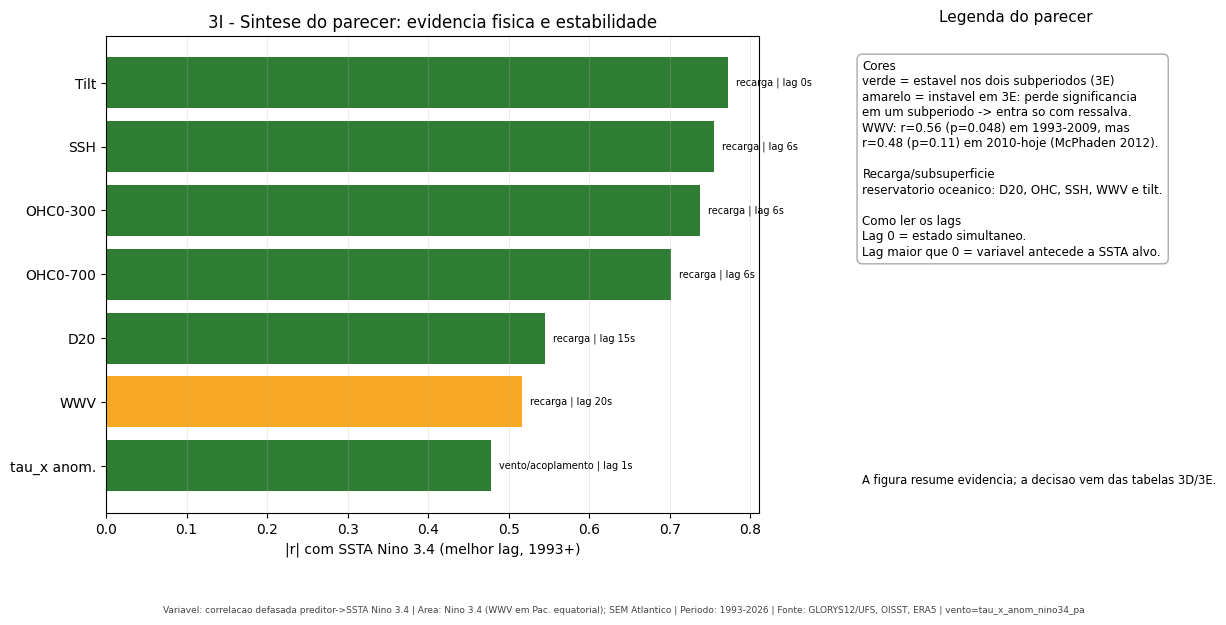

[figura] data\processed\figures\fase3\3I2_antecipacao_pico.png


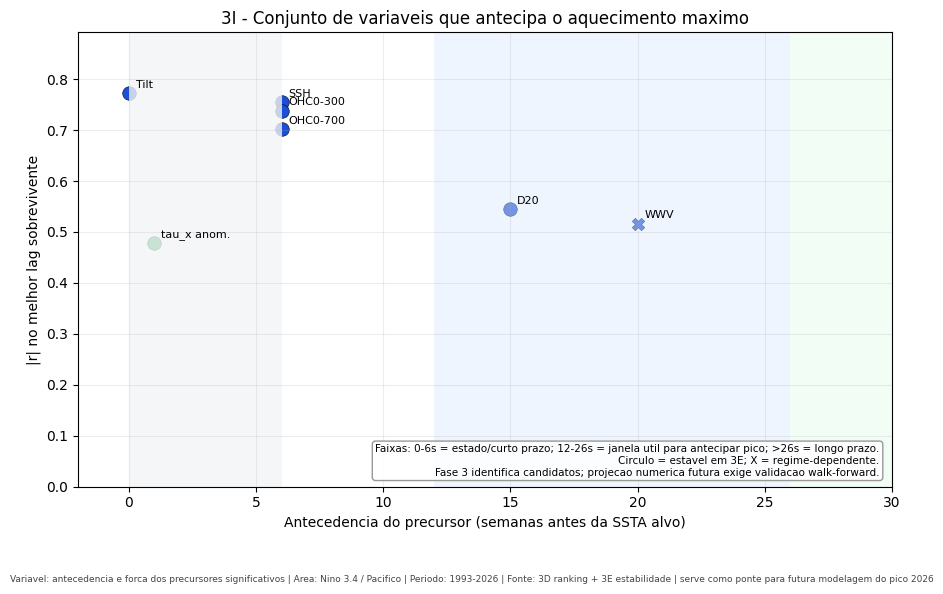

In [5]:
# Figura-sintese 1: ranking executivo e legenda de conceitos.
conc2 = conc.sort_values('abs_r', ascending=False)
fig, (ax, ax_note) = plt.subplots(1, 2, figsize=(13.8, 6.2), gridspec_kw={'width_ratios':[2.35, 1.15]})
cor = conc2['estavel_3E'].map({True:'#2e7d32', False:'#f9a825'})
y = np.arange(len(conc2))
ax.barh(y, conc2['abs_r'], color=cor)
ax.set_yticks(y)
ax.set_yticklabels(conc2['rotulo'])
for i, (_, r) in enumerate(conc2.iterrows()):
    ax.text(r['abs_r']+.01, i, f"{r['bloco'].replace('recarga/subsuperficie','recarga')} | lag {int(r['lag_semanas'])}s", va='center', fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('|r| com SSTA Nino 3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese do parecer: evidencia fisica e estabilidade')
ax.grid(axis='x', alpha=.25)
ax_note.axis('off')
ax_note.set_title('Legenda do parecer', fontsize=11, pad=10)
legend_txt = (
    'Cores\n'
    'verde = estavel nos dois subperiodos (3E)\n'
    'amarelo = instavel em 3E: perde significancia\n'
    'em um subperiodo -> entra so com ressalva.\n'
    'WWV: r=0.56 (p=0.048) em 1993-2009, mas\n'
    'r=0.48 (p=0.11) em 2010-hoje (McPhaden 2012).\n\n'
    'Recarga/subsuperficie\n'
    'reservatorio oceanico: D20, OHC, SSH, WWV e tilt.\n\n'
    'Como ler os lags\n'
    'Lag 0 = estado simultaneo.\n'
    'Lag maior que 0 = variavel antecede a SSTA alvo.'
)
ax_note.text(0.02, 0.95, legend_txt, fontsize=8.55, va='top', ha='left', linespacing=1.25, bbox=dict(boxstyle='round,pad=.45', fc='white', ec='0.65', alpha=.95))
ax_note.text(0.02, 0.055, 'A figura resume evidencia; a decisao vem das tabelas 3D/3E.', fontsize=8.3, va='bottom', ha='left')
u.stamp_caption(fig, variavel='correlacao defasada preditor->SSTA Nino 3.4', area='Nino 3.4 (WWV em Pac. equatorial); SEM Atlantico', periodo='1993-2026', fonte='GLORYS12/UFS, OISST, ERA5', extra='vento=tau_x_anom_nino34_pa')
u.save_fig(fig, '3I1_sintese_parecer.png')
plt.show()

# Figura-sintese 2: quais variaveis realmente antecipam o pico.
fig, ax = plt.subplots(figsize=(10.5, 5.9))
colors = conc['bloco'].map({'recarga/subsuperficie':'#1d4ed8', 'vento/acoplamento':'#16a34a'}).fillna('#6b7280')
markers = conc['estavel_3E'].map({True:'o', False:'X'})
for idx, r in conc.iterrows():
    ax.scatter(r['lag_semanas'], r['abs_r'], s=95 if r['estavel_3E'] else 80, color=colors.loc[idx], marker=markers.loc[idx], edgecolor='k', linewidth=.4)
    ax.annotate(r['rotulo'], (r['lag_semanas'], r['abs_r']), xytext=(5,4), textcoords='offset points', fontsize=8)
ax.axvspan(0, 6, color='#f3f4f6', alpha=.8, lw=0)
ax.axvspan(12, 26, color='#dbeafe', alpha=.45, lw=0)
ax.axvspan(26, 79, color='#dcfce7', alpha=.35, lw=0)
ax.set_xlim(-2, max(30, conc['lag_semanas'].max()+8))
ax.set_ylim(0, min(1, conc['abs_r'].max()+0.12))
ax.set_xlabel('Antecedencia do precursor (semanas antes da SSTA alvo)')
ax.set_ylabel('|r| no melhor lag sobrevivente')
ax.set_title('3I - Conjunto de variaveis que antecipa o aquecimento maximo')
ax.grid(alpha=.22)
u.add_note(ax, 'Faixas: 0-6s = estado/curto prazo; 12-26s = janela util para antecipar pico; >26s = longo prazo.\nCirculo = estavel em 3E; X = regime-dependente.\nFase 3 identifica candidatos; projecao numerica futura exige validacao walk-forward.', loc='lower right')
u.stamp_caption(fig, variavel='antecedencia e forca dos precursores significativos', area='Nino 3.4 / Pacifico', periodo='1993-2026', fonte='3D ranking + 3E estabilidade', extra='serve como ponte para futura modelagem do pico 2026')
u.save_fig(fig, '3I2_antecipacao_pico.png')
plt.show()

In [6]:
# HINDCAST PREDITIVO: triagem flat LOO + avaliacao nested LOO do protocolo de selecao.
# Referencias metodologicas:
# - WMO SVSLRF: verificacao por hindcast, skill contra climatologia cross-validada.
# - Cawley & Talbot (2010) / Ambroise & McLachlan (2002): selecao de modelo fora do loop
#   de teste gera vies otimista; a selecao precisa ocorrer dentro do treino.
# - Meinen & McPhaden (2000) / Jin (1997): recarga/WWV/D20/vento como base fisica ENSO.
w = pd.read_csv(u.FEAT/'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev_h = u.events_noaa()
LEADS = [4, 6, 8, 12, 15, 20, 26]
CAND = ['d20_m','wwv','ohc_0_300','ohc_0_700','ssh_m','tilt_m','tau_x_anom_nino34_pa']
rows = []
for v in CAND:
    for L in LEADS:
        _, met = u.loo_peak_hindcast(w, ev_h, {v: L})
        met.update({'variavel': v, 'rotulo': u.var_label(v, short=True), 'lead_semanas': L})
        rows.append(met)
skill_var = pd.DataFrame(rows)[['variavel','rotulo','lead_semanas','n_eventos','r_loo','mae_loo_c','mae_climatologia_c','skill_vs_climatologia']]
u.save_table(skill_var, 'phase3I_skill_por_variavel.csv', index=False)
melhor = skill_var.sort_values('skill_vs_climatologia', ascending=False).groupby('variavel').head(1).sort_values('skill_vs_climatologia', ascending=False)
antec = skill_var.query('skill_vs_climatologia > 0').groupby('variavel')['lead_semanas'].max().rename('antecedencia_max_util_sem')
melhor = melhor.merge(antec, on='variavel', how='left')
print('Triagem por variavel (flat LOO; nao inclui selecao de modelo):')
print(melhor.to_string(index=False))

# Candidatos fisicos pre-especificados: poucos graus de liberdade e horizontes fixos.
candidates = u.candidate_peak_specs(horizons=(8, 12, 15, 20, 26))
cand_public = pd.DataFrame([{k:v for k,v in c.items() if k != 'spec'} for c in candidates])
u.save_table(cand_public, 'phase3I_modelos_candidatos.csv', index=False)

# Tabela flat LOO por candidato: util para diagnostico, mas nao e a estimativa final de generalizacao.
best_protocol, skill_h_all = u.select_best_spec_by_loo(w, ev_h, candidates)
skill_h = skill_h_all[['modelo','familia','horizonte_sem','variaveis','n_preditores','n_eventos','r_loo','mae_loo_c','mae_climatologia_c','skill_vs_climatologia','residuo_std_c']]
u.save_table(skill_h, 'phase3I_skill_horizontes.csv', index=False)
print('\nTop candidatos por flat LOO (triagem):')
print(skill_h.head(12).to_string(index=False))

# Avaliacao defensavel: cada evento externo e previsto por um modelo escolhido apenas nos outros eventos.
nested_res, nested_met, nested_sel = u.nested_loo_peak_hindcast(w, ev_h, candidates)
u.save_table(nested_res, 'phase3I_nested_loo_eventos.csv', index=False)
u.save_table(pd.DataFrame([nested_met]), 'phase3I_nested_loo_metricas.csv', index=False)
u.save_table(nested_sel, 'phase3I_nested_loo_selecao.csv', index=False)
print('\nMetricas nested LOO do protocolo completo (selecao+ajuste):')
print(pd.DataFrame([nested_met]).T.to_string())

refs = pd.DataFrame([
    {'uso':'recarga ENSO','referencia':'Jin, F.-F. (1997), equatorial ocean recharge paradigm for ENSO','url':'https://doi.org/10.1175/1520-0469(1997)054<0811:AEORPF>2.0.CO;2'},
    {'uso':'WWV/D20/vento como precursores fisicos','referencia':'Meinen & McPhaden (2000), Observations of Warm Water Volume Changes...','url':'https://www.pmel.noaa.gov/pubs/outstand/mein2119/mein2119.shtml'},
    {'uso':'verificacao hindcast/skill','referencia':'WMO Lead Centre, Verification Hindcast / SVSLRF','url':'https://wmolc.org/contents/index/Verification%2BHindcast'},
    {'uso':'skill ENSO por hindcasts/modelos','referencia':'Barnston et al. (2012), Skill of Real-Time Seasonal ENSO Model Predictions','url':'https://doi.org/10.1175/BAMS-D-11-00111.1'},
    {'uso':'controle de vies de selecao','referencia':'Ambroise & McLachlan (2002), Selection bias in gene extraction...','url':'https://ambroise.cloud/publications/arti_ambroise2002selection/index.html'},
    {'uso':'controle de vies de selecao','referencia':'Cawley & Talbot (2010), On over-fitting in model selection...','url':'https://www.jmlr.org/papers/v11/cawley10a.html'},
])
u.save_table(refs, 'phase3I_referencias_metodologicas.csv', index=False)


[tabela] data\processed\parquet\statistics\phase3I_skill_por_variavel.csv
Triagem por variavel (flat LOO; nao inclui selecao de modelo):
            variavel      rotulo  lead_semanas  n_eventos  r_loo  mae_loo_c  mae_climatologia_c  skill_vs_climatologia  antecedencia_max_util_sem
           ohc_0_300    OHC0-300            20         12  0.866      0.214               0.556                  0.615                         26
               ssh_m         SSH            20         12  0.793      0.240               0.556                  0.568                         26
tau_x_anom_nino34_pa tau_x anom.            15         12  0.851      0.276               0.556                  0.504                         26
           ohc_0_700    OHC0-700            20         12  0.801      0.278               0.556                  0.501                         26
              tilt_m        Tilt            15         12  0.726      0.353               0.556                  0.366               

[tabela] data\processed\parquet\statistics\phase3I_skill_horizontes.csv

Top candidatos por flat LOO (triagem):
           modelo       familia  horizonte_sem                            variaveis  n_preditores  n_eventos  r_loo  mae_loo_c  mae_climatologia_c  skill_vs_climatologia  residuo_std_c
       ohc300_20w        ohc300             20                            ohc_0_300             1         12  0.866      0.214               0.556                  0.615          0.304
wind_recharge_15w wind_recharge             15 ohc_0_300+ssh_m+tau_x_anom_nino34_pa             3         12  0.888      0.227               0.556                  0.593          0.281
          ssh_20w           ssh             20                                ssh_m             1         12  0.793      0.240               0.556                  0.568          0.371
        tau_x_15w         tau_x             15                 tau_x_anom_nino34_pa             1         12  0.851      0.276               0.556  

[tabela] data\processed\parquet\statistics\phase3I_nested_loo_eventos.csv
[tabela] data\processed\parquet\statistics\phase3I_nested_loo_metricas.csv
[tabela] data\processed\parquet\statistics\phase3I_nested_loo_selecao.csv

Metricas nested LOO do protocolo completo (selecao+ajuste):
                                                                                                               0
n_eventos                                                                                                     12
r_nested_loo                                                                                               0.738
mae_nested_loo_c                                                                                           0.379
rmse_nested_loo_c                                                                                          0.465
mae_climatologia_c                                                                                         0.556
skill_vs_climatologia                 

WindowsPath('C:/DEV/NINO26/data/processed/parquet/statistics/phase3I_referencias_metodologicas.csv')

[tabela] data\processed\parquet\statistics\phase3I_projecao_pico_2026.csv
                                                                                                                                                        0
pico_projetado_c                                                                                                                                     1.93
ultima_semana_dado                                                                                                                             2026-06-14
antecedencia_min_sem                                                                                                                                   20
antecedencia_max_sem                                                                                                                                   20
janela_pico_projetada_ini                                                                                                                      2026-11-01
ja

[figura] data\processed\figures\fase3\3I3_previsao_condicional_nested.png


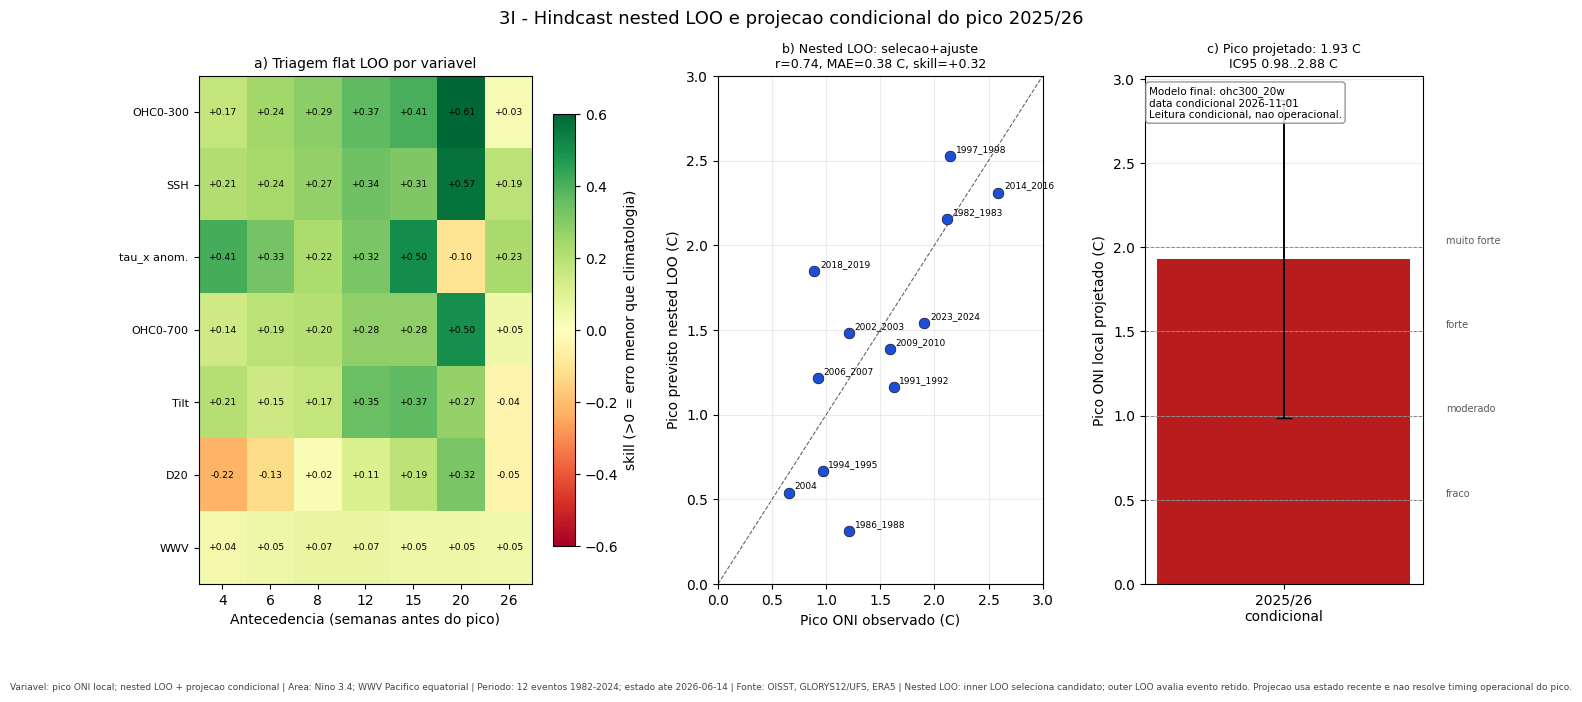

In [7]:
# Projecao condicional do pico 2026 + figura do protocolo nested LOO.
# O modelo final e selecionado por LOO em todos os eventos historicos, mas o desempenho reportado
# vem do nested LOO acima, que avalia a regra completa de selecao + ajuste.
H_STAR = int(best_protocol['horizonte_sem'])
best_vars = str(best_protocol['variaveis']).split('+')
spec_star = best_protocol['spec']
res_flat_star, met_flat_star = u.loo_peak_hindcast(w, ev_h, spec_star)
proj = u.fit_and_project_peak(w, ev_h, spec_star)
last_w = pd.to_datetime(proj['ultima_semana_dado'])
proj['antecedencia_min_sem'], proj['antecedencia_max_sem'] = int(min(spec_star.values())), int(max(spec_star.values()))
proj['janela_pico_projetada_ini'] = str((last_w + pd.Timedelta(weeks=int(min(spec_star.values())))).date())
proj['janela_pico_projetada_fim'] = str((last_w + pd.Timedelta(weeks=int(max(spec_star.values())))).date())
if proj['janela_pico_projetada_ini'] == proj['janela_pico_projetada_fim']:
    proj['janela_pico_projetada_label'] = f"data condicional {proj['janela_pico_projetada_ini']}"
else:
    proj['janela_pico_projetada_label'] = f"janela condicional {proj['janela_pico_projetada_ini']} a {proj['janela_pico_projetada_fim']}"
ic = 1.96 * (nested_met['residuo_std_c'] if np.isfinite(nested_met['residuo_std_c']) else met_flat_star['residuo_std_c'])
proj_row = {**{k: v for k, v in proj.items() if k != 'valores_atuais'},
            'modelo': best_protocol['modelo'], 'familia': best_protocol['familia'], 'variaveis': best_protocol['variaveis'],
            'horizonte_sem': H_STAR,
            'r_loo': nested_met['r_nested_loo'], 'mae_loo_c': nested_met['mae_nested_loo_c'],
            'skill_vs_climatologia': nested_met['skill_vs_climatologia'],
            'r_flat_loo_modelo_final': met_flat_star['r_loo'], 'mae_flat_loo_modelo_final_c': met_flat_star['mae_loo_c'],
            'ic95_baixo_c': round(proj['pico_projetado_c'] - ic, 3), 'ic95_alto_c': round(proj['pico_projetado_c'] + ic, 3),
            'validacao': nested_met['protocolo'],
            'leitura': 'projecao condicional exploratoria: amplitude do pico assumindo que o estado atual e precursor de um pico ~H semanas a frente'}
u.save_table(pd.DataFrame([proj_row]), 'phase3I_projecao_pico_2026.csv', index=False)
print(pd.DataFrame([proj_row]).T.to_string())

fig = plt.figure(figsize=(15.8, 6.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1.05, 0.9], wspace=0.3)
# (a) skill flat LOO por variavel x antecedencia: triagem de preditores.
axa = fig.add_subplot(gs[0])
piv = skill_var.pivot(index='rotulo', columns='lead_semanas', values='skill_vs_climatologia')
piv = piv.reindex(list(melhor['rotulo']))
im = axa.imshow(piv.values, cmap='RdYlGn', vmin=-0.6, vmax=0.6, aspect='auto')
axa.set_xticks(range(len(piv.columns))); axa.set_xticklabels(piv.columns)
axa.set_yticks(range(len(piv.index))); axa.set_yticklabels(piv.index, fontsize=8)
for ii in range(piv.shape[0]):
    for jj in range(piv.shape[1]):
        axa.text(jj, ii, f'{piv.values[ii, jj]:+.2f}', ha='center', va='center', fontsize=6.7, color='k')
axa.set_xlabel('Antecedencia (semanas antes do pico)')
axa.set_title('a) Triagem flat LOO por variavel', fontsize=10)
fig.colorbar(im, ax=axa, shrink=0.85, label='skill (>0 = erro menor que climatologia)')
# (b) observado vs previsto nested LOO: avalia selecao + ajuste.
axb = fig.add_subplot(gs[1])
col_pred = 'oni_pico_prev_nested_loo_c'
axb.scatter(nested_res['oni_pico_obs_c'], nested_res[col_pred], s=60, color='#1d4ed8', edgecolor='k', lw=.4, zorder=3)
for _, rr in nested_res.iterrows():
    axb.annotate(str(rr['event_id']).replace('el_nino_oisst_',''), (rr['oni_pico_obs_c'], rr[col_pred]), xytext=(4,3), textcoords='offset points', fontsize=6.5)
lims = [0, max(3.0, float(nested_res[['oni_pico_obs_c', col_pred]].max().max())+0.3)]
axb.plot(lims, lims, color='0.4', lw=.8, ls='--')
axb.set_xlim(lims); axb.set_ylim(lims)
axb.set_xlabel('Pico ONI observado (C)'); axb.set_ylabel('Pico previsto nested LOO (C)')
axb.set_title(f"b) Nested LOO: selecao+ajuste\nr={nested_met['r_nested_loo']:.2f}, MAE={nested_met['mae_nested_loo_c']:.2f} C, skill={nested_met['skill_vs_climatologia']:+.2f}", fontsize=9)
axb.grid(alpha=.25)
# (c) projecao condicional 2026.
axc = fig.add_subplot(gs[2])
axc.bar([0], [proj['pico_projetado_c']], color='#b91c1c', width=.5)
axc.errorbar([0], [proj['pico_projetado_c']], yerr=[[ic],[ic]], color='k', capsize=6, lw=1.4)
for lim, nome in [(0.5,'fraco'),(1.0,'moderado'),(1.5,'forte'),(2.0,'muito forte')]:
    axc.axhline(lim, color='0.55', lw=.7, ls='--')
    axc.text(0.32, lim+0.02, nome, fontsize=7, color='0.35')
axc.set_xticks([0]); axc.set_xticklabels(['2025/26\ncondicional'])
axc.set_ylabel('Pico ONI local projetado (C)')
axc.set_title(f"c) Pico projetado: {proj['pico_projetado_c']:.2f} C\nIC95 {proj_row['ic95_baixo_c']:.2f}..{proj_row['ic95_alto_c']:.2f} C", fontsize=9)
axc.grid(axis='y', alpha=.25)
u.add_note(axc, f"Modelo final: {best_protocol['modelo']}\n{proj_row['janela_pico_projetada_label']}\nLeitura condicional, nao operacional.", loc='upper left')
fig.suptitle('3I - Hindcast nested LOO e projecao condicional do pico 2025/26', fontsize=13)
u.stamp_caption(fig, variavel='pico ONI local; nested LOO + projecao condicional', area='Nino 3.4; WWV Pacifico equatorial', periodo=f"12 eventos 1982-2024; estado ate {proj['ultima_semana_dado']}", fonte='OISST, GLORYS12/UFS, ERA5', extra='Nested LOO: inner LOO seleciona candidato; outer LOO avalia evento retido. Projecao usa estado recente e nao resolve timing operacional do pico.')
u.save_fig(fig, '3I3_previsao_condicional_nested.png')
plt.show()


**Veredito integrado (Pacifico).** A Fase 3 entrega tres leituras encadeadas: (i) **diagnostico** - o bloco de recarga/subsuperficie (D20, SSH, OHC, WWV, tilt) descreve o reservatorio que permite a amplificacao da SSTA, com `tau_x_anom` como acoplamento vento-superficie; (ii) **triagem preditiva** - o LOO simples por variavel indica quais precursores carregam sinal de antecedencia; (iii) **validacao do protocolo** - o nested LOO avalia a regra completa de escolher modelo/horizonte dentro do treino e prever o evento retido. A projecao 2025/26 passa a ser explicitamente **condicional e exploratoria**, nao operacional. OHC/SSH/tau_x continuam como os sinais mais fortes; WWV entra como variavel fisica classica de recarga, mas com ressalva local por instabilidade pos-2010 (3E).


In [8]:
# exporta texto integrado atualizado para o parecer
entra = ', '.join(conc[~conc['uso_parecer'].str.contains('ressalva', regex=False)]['variavel'].tolist())
ressalva = ', '.join(conc[conc['uso_parecer'].str.contains('ressalva', regex=False)]['variavel'].tolist())
prioritarios = ', '.join(antecip.query("interpreta_para_2026 == 'priorizar na futura projecao de pico'")['variavel'].tolist())
estado = est.iloc[0]
linhas = []
for _, r in media.iterrows():
    linhas.append(f"`{r['grupo']}`: n={int(r['n_eventos'])}, pico ONI medio {r['oni_pico_medio_c']} C, duracao media {r['duracao_media_estacoes_oni']} estacoes, crescimento medio {r['crescimento_medio_c_mes']} C/mes e decaimento medio {r['decaimento_medio_c_mes']} C/mes.")
classes_txt = '\n\n'.join(linhas)
texto = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4. O bloco de recarga/subsuperficie (D20/OHC/SSH/WWV/tilt) domina a interpretacao do aquecimento maximo; `tau_x_anom_nino34_pa` representa acoplamento vento-superficie. Variaveis prioritarias para uma futura projecao do pico: {prioritarios or 'nenhuma variavel passou simultaneamente pelos criterios de antecedencia e estabilidade'}.

## Definicao NOAA/ONI local
Evento El Nino = media movel de 3 meses da SSTA Nino 3.4 >=+0.5 C por pelo menos 5 estacoes moveis sobrepostas. Intensidade = pico dessa media: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. O CPC/NOAA tambem exige evidencia atmosferica; aqui o acoplamento e avaliado por proxy local (`tau_x_anom_nino34_pa`), nao como declaracao oficial.

## Relacoes que entram no parecer
Entram: {entra}. Entram com ressalva/regime-dependencia: {ressalva}. Relacoes instaveis nao sao descartadas automaticamente, mas nao devem ser usadas sozinhas para projetar pico.

## Classes NOAA
{classes_txt}

## Estado 2025/26
Ultimo dado diario OISST: {estado['ultimo_dia']}, SSTA diaria {estado['ssta_diaria_c']} C. Leitura: {estado['leitura']}.

## Hindcast nested LOO e projecao condicional
Metodo agora adotado: candidatos fisicos pre-especificados (`phase3I_modelos_candidatos.csv`), loop interno LOO para escolher modelo/horizonte no treino, loop externo LOO para prever o evento retido. Resultado do protocolo completo: r_nested_loo={proj_row['r_loo']}, MAE={proj_row['mae_loo_c']} C, skill vs climatologia={proj_row['skill_vs_climatologia']}. Modelo final selecionado em todo o historico: {proj_row['modelo']} ({proj_row['variaveis']}) no horizonte de {proj_row['horizonte_sem']} semanas. Projecao condicional do pico 2025/26: {proj_row['pico_projetado_c']} C (IC95 {proj_row['ic95_baixo_c']} a {proj_row['ic95_alto_c']} C), {proj_row['janela_pico_projetada_label']}. Isto estima amplitude condicionada ao estado recente; ainda nao e previsao operacional de timing.

## Referencias metodologicas
- Jin (1997) e Meinen & McPhaden (2000): paradigma de recarga ENSO, D20/WWV/vento/SST.
- WMO SVSLRF e Barnston et al. (2012): verificacao por hindcast e skill contra climatologia.
- Ambroise & McLachlan (2002) e Cawley & Talbot (2010): selecao de modelo deve ocorrer dentro do loop de treino para evitar vies otimista.

## Proxima decisao
A Fase 3 passa a entregar uma avaliacao preditiva exploratoria defensavel por nested LOO. A Fase 5 deve transformar isso em previsao operacional com walk-forward temporal, embargo, barreira de primavera, baseline de persistencia amortecida e previsao simultanea de timing + amplitude.
"""
out = u.STATS / 'phase3I_interpretacao_integrada.md'
out.write_text(texto, encoding='utf-8')
print(f"[texto] {out.relative_to(u.ROOT)}")

[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md
